Previously done methodology of training only on benign samples and testing on attack days didn't work really well.

The pipeline we will be following here:-

1. Combine all the days into one.

2. Remove inf/nan values

3. Strip col spaces

4. Drop cols with zero/constant variance or cols which dont contribute any meaning -> prefiltering

5. Remove the Skewness on train (reuse the already created function). Fit the same in on the test Data .

6. Map label column benign to 0 and rest others to 1

7. Split into two branches here:


    First Method:-

        Standard scaler ->3 PCA models Comparision (One with varainc= 90, One with variance = 95 and another with 25 features) ->test train(80,20 with stratify)
        
        This data to 2 Isolation Forest models (n_estimators = 100: Number of isolation trees • max_samples = auto
        • contamination = 0.1, second witrh n_estimators=500,    max_samples=512,    contamination=0.03)
        
        Test on test set and Evaluation results roc graph,confusion and metric


    Second Method:-

        2nd branch min-max -> Use Variance Thresholding to drop redundant features  -> test train(80,20 with stratify) then     
        train the 2 Isolation Forest models

8. Evalution roc graph,classifction report

In [ ]:
import numpy as np
import pandas as pd
import copy
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, accuracy_score
)
import gc


In [ ]:
# 1. List your exact file paths here
file_paths = [
    r"MachineLearningCVE-20260321T032941Z-3-001/Monday-WorkingHours.pcap_ISCX.csv",
    r"MachineLearningCVE-20260321T032941Z-3-001/Tuesday-WorkingHours.pcap_ISCX.csv",
    r"MachineLearningCVE-20260321T032941Z-3-001/Wednesday-workingHours.pcap_ISCX.csv",
    r"MachineLearningCVE-20260321T032941Z-3-001/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    r"MachineLearningCVE-20260321T032941Z-3-001/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    r"MachineLearningCVE-20260321T032941Z-3-001/Friday-WorkingHours-Morning.pcap_ISCX.csv",
    r"MachineLearningCVE-20260321T032941Z-3-001/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    r"MachineLearningCVE-20260321T032941Z-3-001/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
]

all_chunks = []

for path in file_paths:
    print(f"Loading: {path}")
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    # DOWNCASTING: This is the key to stopping the MemoryError
    # Convert all 64-bit floats to 32-bit (saves 50% RAM per column)
    fcols = df.select_dtypes('float64').columns
    df[fcols] = df[fcols].astype('float32')

    # Convert integers to the smallest possible unsigned format
    icols = df.select_dtypes('int64').columns
    for col in icols:
        if df[col].max() < 255:
            df[col] = df[col].astype(np.uint8)
        elif df[col].max() < 65535:
            df[col] = df[col].astype(np.uint16)
        else:
            df[col] = df[col].astype(np.uint32)

    all_chunks.append(df)
    print(f"Memory saved for this chunk. Current size: {df.memory_usage().sum() / 1024**2:.2f} MB")

# 2. Merge everything together
print("Combining all files into one DataFrame...")
cd = pd.concat(all_chunks, ignore_index=True)

# 3. Clear the temporary list to free up the "double" memory
del all_chunks
gc.collect()

# 4. Final step: Convert Label to binary (0 for Benign, 1 for Attack)
# Using uint8 for the label saves a massive amount of space over int64
cd['Label'] = (cd['Label'].str.strip() != 'BENIGN').astype(np.uint8)

print("--- FINISHED ---")
print(f"Final Row Count: {len(cd)}")
print(f"Final Memory Usage: {cd.memory_usage().sum() / 1024**2:.2f} MB")

Loading: MachineLearningCVE-20260321T032941Z-3-001/Monday-WorkingHours.pcap_ISCX.csv
Memory saved for this chunk. Current size: 129.27 MB
Loading: MachineLearningCVE-20260321T032941Z-3-001/Tuesday-WorkingHours.pcap_ISCX.csv
Memory saved for this chunk. Current size: 107.10 MB
Loading: MachineLearningCVE-20260321T032941Z-3-001/Wednesday-workingHours.pcap_ISCX.csv
Memory saved for this chunk. Current size: 167.48 MB
Loading: MachineLearningCVE-20260321T032941Z-3-001/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Memory saved for this chunk. Current size: 67.11 MB
Loading: MachineLearningCVE-20260321T032941Z-3-001/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Memory saved for this chunk. Current size: 41.24 MB
Loading: MachineLearningCVE-20260321T032941Z-3-001/Friday-WorkingHours-Morning.pcap_ISCX.csv
Memory saved for this chunk. Current size: 46.24 MB
Loading: MachineLearningCVE-20260321T032941Z-3-001/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Memory saved

In [ ]:
print(len(cd))

2827876


In [ ]:
cd.columns = cd.columns.str.strip()
DROP_COLS = [
    'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate',
    'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate',
    'Fwd Header Length.1',
    'Bwd PSH Flags',
    'Fwd URG Flags',
    'Bwd URG Flags',
    'CWE Flag Count',
]


X = cd.drop(columns=['Label'] + DROP_COLS, errors='ignore')
y = cd['Label']

attack_rate = y.mean()
print(f"Feature shape   : {X.shape}")
print(f"Attack rate     : {attack_rate:.4f}  ({y.sum():,} attacks / {len(y):,} total)")

Feature shape   : (2827876, 67)
Attack rate     : 0.1968  (556,556 attacks / 2,827,876 total)


In [ ]:
def fit_skew_transformer(df_train, mild_threshold=0.5, high_threshold=1.0):
    transformation_map = {}

    for col in df_train.columns:
        skewness = df_train[col].skew()
        abs_skew  = abs(skewness)
        direction = 1 if skewness > 0 else -1

        if abs_skew <= mild_threshold:
            transformation_map[col] = {
                'type': 'none'
            }

        elif abs_skew <= high_threshold:
            if direction == 1:
                shift = abs(df_train[col].min()) + 1 if df_train[col].min() < 0 else 0
                transformation_map[col] = {
                    'type' : 'sqrt',
                    'shift': shift
                }
            else:
                col_max = df_train[col].max()
                transformation_map[col] = {
                    'type'   : 'reflected_sqrt',
                    'col_max': col_max
                }

        elif abs_skew <= 2.0:
            if direction == 1:
                shift = abs(df_train[col].min()) + 1 if df_train[col].min() < 0 else 0
                transformation_map[col] = {
                    'type' : 'log1p',
                    'shift': shift
                }
            else:
                col_max = df_train[col].max()
                transformation_map[col] = {
                    'type'   : 'reflected_log1p',
                    'col_max': col_max
                }

        else:
            # Fit Yeo-Johnson on train — lambda learned here
            _, lambda_ = stats.yeojohnson(df_train[col])
            transformation_map[col] = {
                'type'  : 'yeojohnson',
                'lambda': lambda_
            }

    return transformation_map


def apply_skew_transformer(df, transformation_map):
    df_out = df.copy()

    for col, params in transformation_map.items():
        t = params['type']

        if t == 'none':
            pass

        elif t == 'sqrt':
            df_out[col] = np.sqrt(df[col] + params['shift'])

        elif t == 'reflected_sqrt':
            reflected = params['col_max'] + 1 - df[col]
            df_out[col] = -np.sqrt(reflected)

        elif t == 'log1p':
            df_out[col] = np.log1p(df[col] + params['shift'])

        elif t == 'reflected_log1p':
            reflected = params['col_max'] + 1 - df[col]
            df_out[col] = -np.log1p(reflected)

        elif t == 'yeojohnson':
            # Apply with the lambda learned from train
            df_out[col] = stats.yeojohnson(df[col], lmbda=params['lambda'])

    return df_out

In [ ]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train : {X_train_raw.shape}  attack rate: {y_train.mean():.4f}")
print(f"Test  : {X_test_raw.shape}   attack rate: {y_test.mean():.4f}")

print("\nFitting skew transformer on train...")
skew_map = fit_skew_transformer(X_train_raw)


X_train = apply_skew_transformer(X_train_raw, skew_map)
X_test  = apply_skew_transformer(X_test_raw,  skew_map)


improved = sum(1 for v in skew_map.values() if v['type'] != 'none')
print(f"Transformations applied to: {improved} / {len(skew_map)} features")
print(f"Train shape after skew: {X_train.shape}")
print(f"Test  shape after skew: {X_test.shape}")

Train : (2262300, 67)  attack rate: 0.1968
Test  : (565576, 67)   attack rate: 0.1968

Fitting skew transformer on train...
Transformations applied to: 66 / 67 features
Train shape after skew: (2262300, 67)
Test  shape after skew: (565576, 67)


### Creating 2 Isolation Forest models

In [ ]:

IF_CONFIGS = {
    'if_A (n=100, cont=0.10)': IsolationForest(
        n_estimators=100, max_samples='auto',
        contamination=0.1, random_state=42
    ),
    'if_B (n=500, cont=0.03)': IsolationForest(
        n_estimators=500, max_samples=512,
        contamination=0.03, random_state=42
    ),
}

### Function to Train the model on X_train and then predict the results on X_Test

In [ ]:
def evaluate(model, X_tr, X_te, y_te, label):
    model.fit(X_tr)
    scores = -model.decision_function(X_te)      # higher = more anomalous
    preds  = (model.predict(X_te) == -1).astype(int)

    auc = roc_auc_score(y_te, scores)
    cm  = confusion_matrix(y_te, preds)

    print(f"\n{'─'*60}")
    print(f"  {label}")
    print(f"  AUC-ROC : {auc:.4f}")
    print(f"{'─'*60}")
    print(classification_report(y_te, preds,
                                 target_names=['Benign', 'Attack'],
                                 digits=4))
    return {
        'label' : label,
        'model' : model,
        'auc'   : auc,
        'cm'    : cm,
        'scores': scores,
        'preds' : preds,
    }

### Method 1

In [ ]:
# Method 1 — StandardScaler → PCA → Isolation Forest

scaler_std = StandardScaler()
X_tr_std   = scaler_std.fit_transform(X_train)
X_te_std   = scaler_std.transform(X_test)

PCA_CONFIGS = {
    'pca_90': PCA(n_components=0.90, random_state=42),
    'pca_95': PCA(n_components=0.95, random_state=42),
    'pca_25': PCA(n_components=25,   random_state=42),
}

pca_splits = {}
print("\nPCA summary:")
for name, pca in PCA_CONFIGS.items():
    tr = pca.fit_transform(X_tr_std)
    te = pca.transform(X_te_std)
    pca_splits[name] = (tr, te)
    print(f"  {name}: {pca.n_components_} components | "
          f"variance explained: {sum(pca.explained_variance_ratio_):.4f}")

branch1 = {}
for pca_name, (tr, te) in pca_splits.items():
    for if_name, if_base in IF_CONFIGS.items():
        key   = f"{pca_name} | {if_name}"
        label = f"B1 | {key}"
        res   = evaluate(copy.deepcopy(if_base), tr, te, y_test, label)
        branch1[key] = res


PCA summary:
  pca_90: 12 components | variance explained: 0.9083
  pca_95: 16 components | variance explained: 0.9540
  pca_25: 25 components | variance explained: 0.9887

────────────────────────────────────────────────────────────
  B1 | pca_90 | if_A (n=100, cont=0.10)
  AUC-ROC : 0.6379
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Benign     0.8006    0.8969    0.8460    454265
      Attack     0.1734    0.0883    0.1170    111311

    accuracy                         0.7377    565576
   macro avg     0.4870    0.4926    0.4815    565576
weighted avg     0.6772    0.7377    0.7025    565576


────────────────────────────────────────────────────────────
  B1 | pca_90 | if_B (n=500, cont=0.03)
  AUC-ROC : 0.6652
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Benign     0.7994    0.9655    0.8746    454265
      Attack     0.0744    

### Method 2


After variance filter  : 63 features (removed 4)
After correlation filter: 36 features (removed 27 correlated)
Dropped: ['Fwd Packet Length Max', 'Bwd Packet Length Max', 'Bwd Packet Length Mean', 'Flow IAT Max', 'Fwd IAT Mean', 'Fwd IAT Max', 'Bwd IAT Mean', 'Bwd IAT Max', 'Bwd Header Length', 'Fwd Packets/s', 'Min Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'SYN Flag Count', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Max', 'Idle Min']


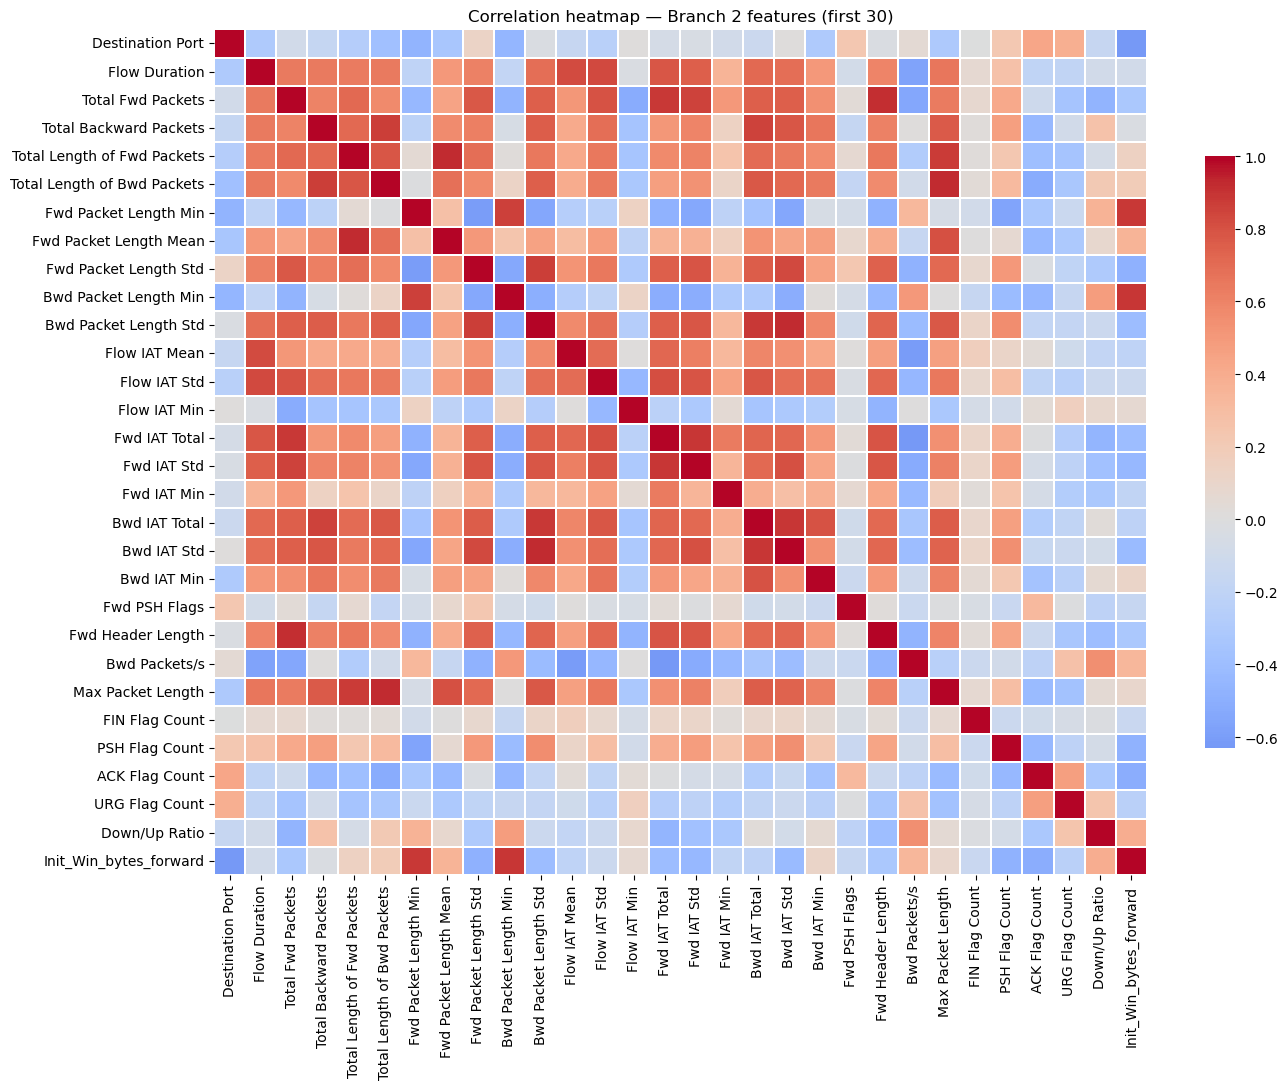


────────────────────────────────────────────────────────────
  B2 | minmax+corr | if_A (n=100, cont=0.10)
  AUC-ROC : 0.6405
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Benign     0.7968    0.8932    0.8423    454265
      Attack     0.1393    0.0705    0.0936    111311

    accuracy                         0.7313    565576
   macro avg     0.4680    0.4819    0.4679    565576
weighted avg     0.6674    0.7313    0.6949    565576


────────────────────────────────────────────────────────────
  B2 | minmax+corr | if_B (n=500, cont=0.03)
  AUC-ROC : 0.6065
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Benign     0.7995    0.9654    0.8747    454265
      Attack     0.0777    0.0119    0.0206    111311

    accuracy                         0.7778    565576
   macro avg     0.4386    0.4887    0.4476    565576
weighted avg     0.6574    

In [ ]:
# Method 2 — MinMaxScaler → Variance filter → Correlation filter → Isolation Forest

scaler_mm  = MinMaxScaler()
X_tr_mm    = scaler_mm.fit_transform(X_train)
X_te_mm    = scaler_mm.transform(X_test)

# ── Variance threshold ────────────────────────────────────────────────────────
var_sel    = VarianceThreshold(threshold=0.001)
X_tr_var   = var_sel.fit_transform(X_tr_mm)
X_te_var   = var_sel.transform(X_te_mm)
var_cols   = X_train.columns[var_sel.get_support()]
print(f"\nAfter variance filter  : {X_tr_var.shape[1]} features "
      f"(removed {X_train.shape[1] - X_tr_var.shape[1]})")

# ── Correlation filter ────────────────────────────────────
X_tr_var_df = pd.DataFrame(X_tr_var, columns=var_cols)
corr_matrix = X_tr_var_df.corr().abs()
upper       = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
corr_drop   = [c for c in upper.columns if any(upper[c] > 0.95)]
corr_keep   = [c for c in var_cols if c not in corr_drop]

X_tr_corr   = X_tr_var_df[corr_keep].values
X_te_corr   = pd.DataFrame(X_te_var, columns=var_cols)[corr_keep].values

print(f"After correlation filter: {X_tr_corr.shape[1]} features "
      f"(removed {len(corr_drop)} correlated)")
print(f"Dropped: {corr_drop}")

# ── Visualise correlation heatmap ───────────
plt.figure(figsize=(14, 11))
sample_cols = corr_keep[:30]
sns.heatmap(
    X_tr_var_df[sample_cols].corr(),
    cmap='coolwarm', center=0, linewidths=0.3,
    xticklabels=sample_cols, yticklabels=sample_cols,
    cbar_kws={'shrink': 0.7}
)
plt.title('Correlation heatmap — Branch 2 features (first 30)', fontsize=12)
plt.tight_layout()
plt.show()

branch2 = {}
for if_name, if_base in IF_CONFIGS.items():
    label = f"B2 | minmax+corr | {if_name}"
    res   = evaluate(copy.deepcopy(if_base), X_tr_corr, X_te_corr, y_test, label)
    branch2[if_name] = res

### Comparision of all the models

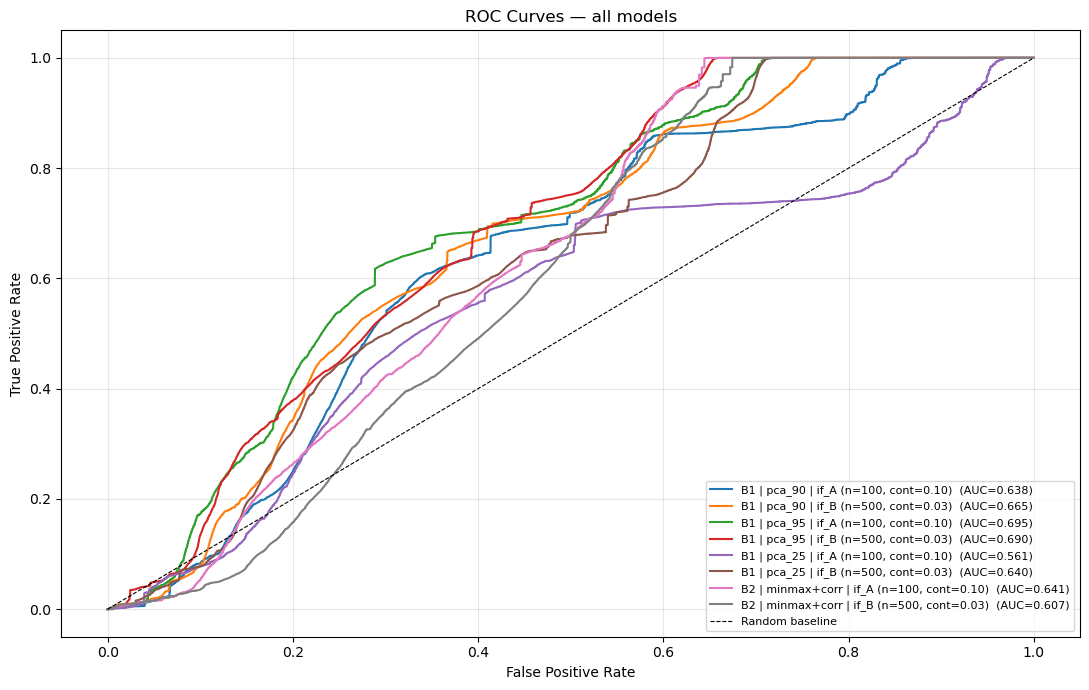

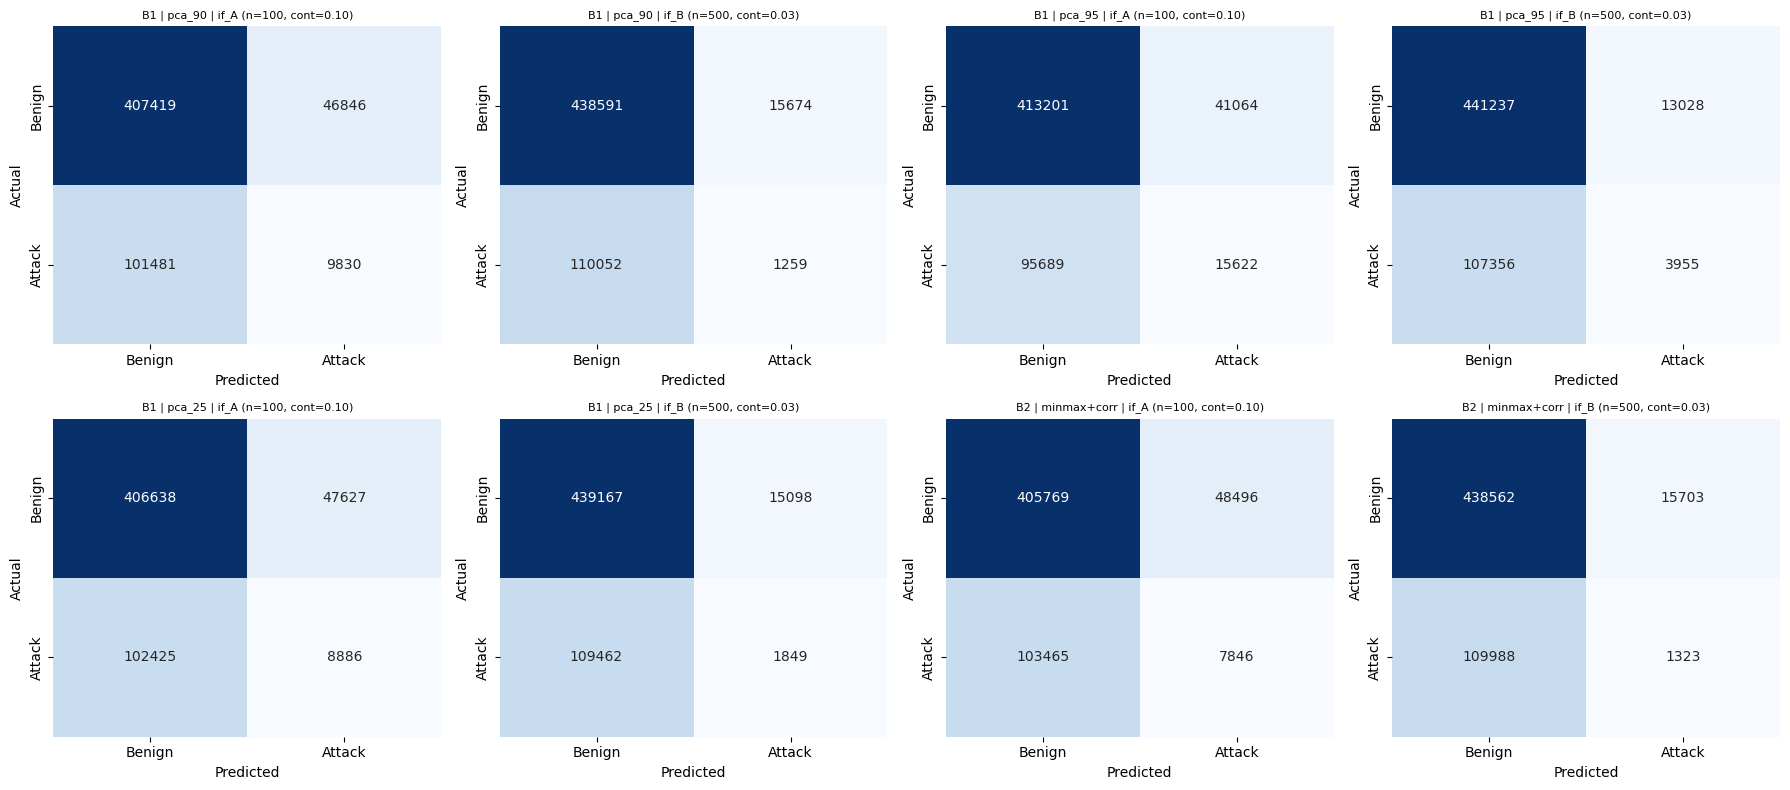


SUMMARY
                                     Model  AUC-ROC  Accuracy  Precision  Recall     F1
     B1 | pca_95 | if_A (n=100, cont=0.10)   0.6951    0.7582     0.2756  0.1403 0.1860
     B1 | pca_95 | if_B (n=500, cont=0.03)   0.6896    0.7871     0.2329  0.0355 0.0617
     B1 | pca_90 | if_B (n=500, cont=0.03)   0.6652    0.7777     0.0744  0.0113 0.0196
B2 | minmax+corr | if_A (n=100, cont=0.10)   0.6405    0.7313     0.1393  0.0705 0.0936
     B1 | pca_25 | if_B (n=500, cont=0.03)   0.6399    0.7798     0.1091  0.0166 0.0288
     B1 | pca_90 | if_A (n=100, cont=0.10)   0.6379    0.7377     0.1734  0.0883 0.1170
B2 | minmax+corr | if_B (n=500, cont=0.03)   0.6065    0.7778     0.0777  0.0119 0.0206
     B1 | pca_25 | if_A (n=100, cont=0.10)   0.5612    0.7347     0.1572  0.0798 0.1059


In [ ]:
# PLOTS

all_results = (
    {f"b1_{k}": v for k, v in branch1.items()} |
    {f"b2_{k}": v for k, v in branch2.items()}
)

# ── ROC curves ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
colors = plt.cm.tab10.colors

for i, res in enumerate(all_results.values()):
    fpr, tpr, _ = roc_curve(y_test, res['scores'])
    ax.plot(fpr, tpr,
            label=f"{res['label']}  (AUC={res['auc']:.3f})",
            color=colors[i % len(colors)], linewidth=1.5)

ax.plot([0,1],[0,1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — all models')
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Confusion matrices ────────────────────────────────────────────────────────
n    = len(all_results)
cols = 4
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 4))
axes = axes.flatten()

for i, res in enumerate(all_results.values()):
    sns.heatmap(res['cm'], annot=True, fmt='d', ax=axes[i],
                cmap='Blues', cbar=False,
                xticklabels=['Benign','Attack'],
                yticklabels=['Benign','Attack'])
    axes[i].set_title(res['label'], fontsize=8)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for res in all_results.values():
    p = res['preds']
    rows.append({
        'Model'    : res['label'],
        'AUC-ROC'  : round(res['auc'], 4),
        'Accuracy' : round(accuracy_score(y_test, p), 4),
        'Precision': round(precision_score(y_test, p, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, p, zero_division=0), 4),
        'F1'       : round(f1_score(y_test, p, zero_division=0), 4),
    })

summary = pd.DataFrame(rows).sort_values('AUC-ROC', ascending=False)
print("\n" + "="*90)
print("SUMMARY")
print("="*90)
print(summary.to_string(index=False))

### Trying by adjusting the contamination hyperparameter

In [ ]:
IF_CONFIGS2={
    'if_C (n=100, cont=0.19)': IsolationForest(
        n_estimators=100, max_samples='auto',
        contamination=0.1, random_state=42
    ),
    'if_D (n=500, cont=0.19)': IsolationForest(
        n_estimators=500, max_samples=512,
        contamination=0.03, random_state=42
    ),
}

In [ ]:
for pca_name, (tr, te) in pca_splits.items():
    for if_name, if_base in IF_CONFIGS2.items():
        key   = f"{pca_name} | {if_name}"
        label = f"B3 | {key}"
        res   = evaluate(copy.deepcopy(if_base), tr, te, y_test, label)
        branch1[key] = res


────────────────────────────────────────────────────────────
  B3 | pca_90 | if_C (n=100, cont=0.19)
  AUC-ROC : 0.6379
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Benign     0.8006    0.8969    0.8460    454265
      Attack     0.1734    0.0883    0.1170    111311

    accuracy                         0.7377    565576
   macro avg     0.4870    0.4926    0.4815    565576
weighted avg     0.6772    0.7377    0.7025    565576


────────────────────────────────────────────────────────────
  B3 | pca_90 | if_D (n=500, cont=0.19)
  AUC-ROC : 0.6652
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Benign     0.7994    0.9655    0.8746    454265
      Attack     0.0744    0.0113    0.0196    111311

    accuracy                         0.7777    565576
   macro avg     0.4369    0.4884    0.4471    565576
weighted avg     0.6567    0.7777    

In [ ]:
for if_name, if_base in IF_CONFIGS2.items():
    label = f"B4 | minmax+corr | {if_name}"
    res   = evaluate(copy.deepcopy(if_base), X_tr_corr, X_te_corr, y_test, label)
    branch2[if_name] = res


────────────────────────────────────────────────────────────
  B4 | minmax+corr | if_C (n=100, cont=0.19)
  AUC-ROC : 0.6405
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Benign     0.7968    0.8932    0.8423    454265
      Attack     0.1393    0.0705    0.0936    111311

    accuracy                         0.7313    565576
   macro avg     0.4680    0.4819    0.4679    565576
weighted avg     0.6674    0.7313    0.6949    565576


────────────────────────────────────────────────────────────
  B4 | minmax+corr | if_D (n=500, cont=0.19)
  AUC-ROC : 0.6065
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Benign     0.7995    0.9654    0.8747    454265
      Attack     0.0777    0.0119    0.0206    111311

    accuracy                         0.7778    565576
   macro avg     0.4386    0.4887    0.4476    565576
weighted avg     0.6574    

### Conclusion

In this notebook we tried two different methodology on the full dataset: -

First method being PCA we got best metrics from the B1 A model PCA = 95% variance

Second method being Min Max Normalisation followed by variance thresholding and correlation filtering and removing highly correlated features the best model being B2 A.

Features with near-zero variance are effectively constants — they carry no discriminative information because every sample has nearly the same value.
4 features (Bwd PSH Flags, Fwd URG Flags, Bwd URG Flags, CWE Flag Count) had variance below the threshold — these are flag fields that were almost never set in the CICIDS 2017 capture, meaning they contribute nothing to separating attacks from benign traffic.

Reasons for method 2:- When two features are >0.95 correlated, they carry almost exactly the same information. Keeping both does not help iForest — it effectively double-counts that dimension during random splitting, making the model behave as if that dimension is twice as important as it actually is. Removing one of each correlated pair gives the remaining features more balanced representation in the tree construction process.

Problems with the above method - While variance in the data is one of the most important aspect to improve to the models accuracy and other metrics solely depending on it the features is making it harder to classify the anamolies. Example: - There might be only 0.1 varaince in a feature but the time it varies might be the time the anamoly occurs.

This might be the case for why the model has shown no improvement even in training over the full dataset.


## In Detail Analysis of errors -> What predictions are going wrong/right and why? (Explainability)